# Dynamical Low-Rank Approximation — a toy low-rank ODE

Self-contained implementation of the algorithm from

> O. Koch and C. Lubich, **Dynamical Low-Rank Approximation**,
> *SIAM J. Matrix Anal. Appl.* 29 (2007), pp. 434-454.

applied to a toy matrix ODE whose solution is genuinely low rank.

## The idea

Rather than recomputing a rank-$r$ best approximation of a time-dependent matrix
$A(t)$ by an SVD at every $t$ (paper eq. (1.1)), DLRA evolves an approximation
$Y(t) = U(t)\,S(t)\,V(t)^\top$ on the manifold $\mathcal{M}_r$ of rank-$r$
matrices so that its derivative is the **orthogonal projection** of the target
derivative onto the tangent space $T_Y\mathcal{M}_r$ (paper eq. (1.2)):

$$\dot Y \in T_Y\mathcal{M}_r \quad\text{such that}\quad \lVert \dot Y - \dot A\rVert \ \text{is minimal.}$$

With $Y=USV^\top$ and $U^\top U = V^\top V = I$, this is equivalent to the
**factor differential equations** (paper eq. (2.8)):

$$\dot S = U^\top Z\, V,\qquad
\dot U = (I-UU^\top)\,Z\,V\,S^{-1},\qquad
\dot V = (I-VV^\top)\,Z^\top U\,S^{-\top},$$

where $Z$ is the target derivative. For **data approximation** $Z=\dot A(t)$; for
a **matrix ODE** $\bar A' = F(\bar A)$ the target is $Z = F(Y)$ evaluated at the
current low-rank approximation (paper §6.4). Only products of $Z$ with the
$r$-column factors are needed — the dense $m\times n$ matrix is never formed.


In [1]:
import numpy as np
from scipy.linalg import expm

import matplotlib.pyplot as plt
%matplotlib inline

rng_seed = 0
np.set_printoptions(precision=4, suppress=True)

## Core DLRA method

The factor ODEs (2.8), an RK4 integrator, and supporting pieces:

- `truncated_svd` supplies the recommended initial value $Y(t_0)=X(t_0)$ (the
  pointwise best rank-$r$ approximation of the initial data).
- `regularized_inv` implements the paper's §6.1 regularization of $S^{-1}$ for
  the small-singular-value regime (with `eps=0` it is the plain inverse).
- The exact factor flow keeps $U,V$ orthonormal (paper §2.2); an explicit
  integrator drifts slightly, so a thin QR folded into $S$ restores it without
  changing $Y=USV^\top$.


In [2]:
def truncated_svd(A, r):
    """Best rank-r factors (U, S, V) of A; S = diag of the top r singular values."""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :r], np.diag(s[:r]), Vt[:r, :].T


def regularized_inv(S, eps=0.0):
    """Inverse of S, optionally regularized (paper §6.1).

    eps > 0 replaces each singular value sigma_i of S by sqrt(sigma_i^2 + eps^2)
    before inverting, taming the S^{-1} terms in eq. (2.8) when S is ill-conditioned.
    """
    if eps <= 0.0:
        return np.linalg.inv(S)
    P, sigma, Qt = np.linalg.svd(S)
    return (Qt.T * (1.0 / np.sqrt(sigma ** 2 + eps ** 2))) @ P.T


def factor_derivative(t, U, S, V, rhs, reg):
    """Right-hand side of the factor ODEs (paper eq. (2.8))."""
    Z = rhs(t, U, S, V)                        # m x n target derivative
    Sinv = regularized_inv(S, reg)

    ZV = Z @ V                                 # m x r
    Sdot = U.T @ ZV                            # U^T Z V
    Udot = (ZV - U @ (U.T @ ZV)) @ Sinv        # (I - U U^T) Z V S^{-1}

    ZtU = Z.T @ U                              # n x r
    Vdot = (ZtU - V @ (V.T @ ZtU)) @ Sinv.T    # (I - V V^T) Z^T U S^{-T}
    return Udot, Sdot, Vdot


def _axpy(a, x, y):
    return (y[0] + a * x[0], y[1] + a * x[1], y[2] + a * x[2])


def _reorthonormalize(U, S, V):
    """Restore U^T U = V^T V = I without changing Y = U S V^T (thin QR into S)."""
    QU, RU = np.linalg.qr(U)
    QV, RV = np.linalg.qr(V)
    return QU, RU @ S @ RV.T, QV


def rk4_step(t, factors, h, rhs, reg=0.0):
    """One classical RK4 step of the factor ODEs, then re-orthonormalize."""
    U, S, V = factors
    k1 = factor_derivative(t, U, S, V, rhs, reg)
    k2 = factor_derivative(t + h / 2, *_axpy(h / 2, k1, factors), rhs=rhs, reg=reg)
    k3 = factor_derivative(t + h / 2, *_axpy(h / 2, k2, factors), rhs=rhs, reg=reg)
    k4 = factor_derivative(t + h, *_axpy(h, k3, factors), rhs=rhs, reg=reg)

    U = U + (h / 6) * (k1[0] + 2 * k2[0] + 2 * k3[0] + k4[0])
    S = S + (h / 6) * (k1[1] + 2 * k2[1] + 2 * k3[1] + k4[1])
    V = V + (h / 6) * (k1[2] + 2 * k2[2] + 2 * k3[2] + k4[2])
    return _reorthonormalize(U, S, V)


def integrate(rhs, factors0, t_grid, reg=0.0):
    """Integrate the DLRA factor ODEs over t_grid, returning factors at each node.

    rhs(t, U, S, V) -> Z (m x n): use Z = Adot(t) for data approximation, or
    Z = F(U S V^T) for a matrix ODE Abar' = F(Abar).
    """
    factors = factors0
    out = [factors]
    for k in range(len(t_grid) - 1):
        h = float(t_grid[k + 1] - t_grid[k])
        factors = rk4_step(float(t_grid[k]), factors, h, rhs, reg)
        out.append(factors)
    return out


def to_dense(factors):
    U, S, V = factors
    return U @ S @ V.T

## The toy ODE (paper §6.5)

The linear matrix ODE

$$\bar A'(t) = L\,\bar A(t) + \bar A(t)\,R,\qquad \bar A(0)=A_0,$$

has the closed-form solution

$$\bar A(t) = e^{tL}\,A_0\,e^{tR}.$$

Because $e^{tL}$ and $e^{tR}$ are invertible for every $t$, we have
$\operatorname{rank}\bar A(t) = \operatorname{rank} A_0$ for all $t$. So if $A_0$
has rank $r$, **the ODE solution lives exactly on $\mathcal{M}_r$** — a clean
toy example of an ODE solution that is low rank.

We solve it with DLRA using the target derivative $Z = F(Y) = LY + YR$ evaluated
at the current low-rank $Y$ — never forming the dense solution.


In [3]:
def random_generator(n, rng, skew_scale, sym_scale):
    """Generator = skew part (rotates singular vectors) + small symmetric part
    (slowly grows/shrinks singular values, so S(t) genuinely evolves)."""
    Msk = rng.standard_normal((n, n))
    Msy = rng.standard_normal((n, n))
    return skew_scale * (Msk - Msk.T) / np.sqrt(n) + sym_scale * (Msy + Msy.T) / np.sqrt(n)


def make_core(n, r, rng, exact_low_rank, tail=1e-2):
    """A0 = W1 diag(sv) W2^T with a spectral gap (the 'effective rank r' setting
    of the paper's first example): r dominant singular values of order 1, then a
    small tail of size ~tail. exact_low_rank zeros the tail entirely (rank == r)."""
    W1, _ = np.linalg.qr(rng.standard_normal((n, n)))
    W2, _ = np.linalg.qr(rng.standard_normal((n, n)))
    sv_top = np.linspace(1.0, 0.4, r)              # r dominant values, all O(1)
    sv_tail = tail * (0.8 ** np.arange(n - r))     # small tail below a clear gap
    sv = np.concatenate([sv_top, sv_tail])
    if exact_low_rank:
        sv[r:] = 0.0
    return (W1 * sv) @ W2.T


def solve(n, r, exact_low_rank, tail=1e-2, n_steps=800, seed=0):
    rng = np.random.default_rng(seed)
    L = random_generator(n, rng, skew_scale=1.5, sym_scale=0.3)
    R = random_generator(n, rng, skew_scale=1.5, sym_scale=0.3)
    A0 = make_core(n, r, rng, exact_low_rank=exact_low_rank, tail=tail)

    t_grid = np.linspace(0.0, 1.0, n_steps + 1)

    # Exact solution of Abar' = L Abar + Abar R on the grid.
    A_exact = [expm(t * L) @ A0 @ expm(t * R) for t in t_grid]

    # DLRA: target derivative F(Y) = L Y + Y R evaluated at the low-rank Y.
    def rhs(t, U, S, V):
        Y = (U @ S) @ V.T
        return L @ Y + Y @ R

    factors = integrate(rhs, truncated_svd(A0, r), t_grid)

    err_YA = np.zeros(len(t_grid))   # DLRA vs exact ODE solution
    err_XA = np.zeros(len(t_grid))   # best rank-r vs exact
    err_YX = np.zeros(len(t_grid))   # DLRA vs best rank-r
    normA = np.zeros(len(t_grid))    # ||A(t)||_F, for relative errors
    sv_exact = np.zeros((len(t_grid), r))
    sv_dlra = np.zeros((len(t_grid), r))
    for k, (A, fac) in enumerate(zip(A_exact, factors)):
        Y = to_dense(fac)
        X = to_dense(truncated_svd(A, r))
        err_YA[k] = np.linalg.norm(Y - A)
        err_XA[k] = np.linalg.norm(X - A)
        err_YX[k] = np.linalg.norm(Y - X)
        normA[k] = np.linalg.norm(A)
        sv_exact[k] = np.linalg.svd(A, compute_uv=False)[:r]
        sv_dlra[k] = np.linalg.svd(fac[1], compute_uv=False)

    return dict(t=t_grid, err_YA=err_YA, err_XA=err_XA, err_YX=err_YX, normA=normA,
                sv_exact=sv_exact, sv_dlra=sv_dlra, A_exact=A_exact,
                n=n, r=r, exact_low_rank=exact_low_rank)


def print_summary(res):
    tag = "exact rank-r" if res["exact_low_rank"] else "approx rank-r"
    rel = lambda e: (e / res["normA"]).max()   # max relative Frobenius error
    print(f"=== {tag} :  n={res['n']}, r={res['r']} ===")
    print(f"  ||A(1)||_F                            = {np.linalg.norm(res['A_exact'][-1]):.4e}")
    print(f"  max_t ||X - A|| / ||A||  (best rank-r)= {rel(res['err_XA']):.3e}")
    print(f"  max_t ||Y - X|| / ||A||  (DLRA-best)  = {rel(res['err_YX']):.3e}")
    print(f"  max_t ||Y - A|| / ||A||  (DLRA-exact) = {rel(res['err_YA']):.3e}")
    if rel(res["err_XA"]) > 1e-6:   # skip when the target is essentially rank r
        print(f"  ratio  max||Y-X|| / max||X-A||        = {res['err_YX'].max()/res['err_XA'].max():.3f}")
        print("  (DLRA nearly attains the best possible rank-r approximation)")

## Case 1 — exact low rank

$A_0$ has rank $r$, so the exact ODE solution is exactly rank $r$. DLRA with
rank $r$ should reproduce it up to time-integration error only.


In [4]:
res_exact = solve(n=40, r=4, exact_low_rank=True, seed=rng_seed)
print_summary(res_exact)

=== exact rank-r :  n=40, r=4 ===
  ||A(1)||_F                            = 1.9090e+00
  max_t ||X - A|| / ||A||  (best rank-r)= 6.184e-15
  max_t ||Y - X|| / ||A||  (DLRA-best)  = 2.432e-11
  max_t ||Y - A|| / ||A||  (DLRA-exact) = 2.432e-11


The best rank-$r$ error is at machine precision (the solution really is rank
$r$), and DLRA matches the exact solution to the RK4 integration error.

## Case 2 — approximate low rank

Now $A_0$ is full rank but has a **spectral gap**: $r$ dominant singular values
of order 1 and a small tail of size $\sim10^{-2}$ (the "effective rank $r$"
setting of the paper's first example). So $\bar A(t)$ is only *approximately*
rank $r$, and no rank-$r$ matrix can do better than the tail.

DLRA with rank $r$ should track the pointwise best rank-$r$ approximation
$X(t)$, with $\lVert Y-X\rVert$ small and $\lVert Y-A\rVert$ essentially equal to
the irreducible best-approximation error $\lVert X-A\rVert$ (paper Thm 5.1 /
Fig. 3.2). It cannot beat $X$ — that is the theory, not a defect.


In [5]:
res_approx = solve(n=40, r=4, exact_low_rank=False, seed=rng_seed)
print_summary(res_approx)

=== approx rank-r :  n=40, r=4 ===
  ||A(1)||_F                            = 1.9091e+00
  max_t ||X - A|| / ||A||  (best rank-r)= 1.134e-02
  max_t ||Y - X|| / ||A||  (DLRA-best)  = 3.088e-03
  max_t ||Y - A|| / ||A||  (DLRA-exact) = 1.134e-02
  ratio  max||Y-X|| / max||X-A||        = 0.295
  (DLRA nearly attains the best possible rank-r approximation)


## Plots

Singular-value tracking for both cases, DLRA reproduction error for the exact
case, and the error curves mirroring the paper's Fig. 3.2 for the approximate case.


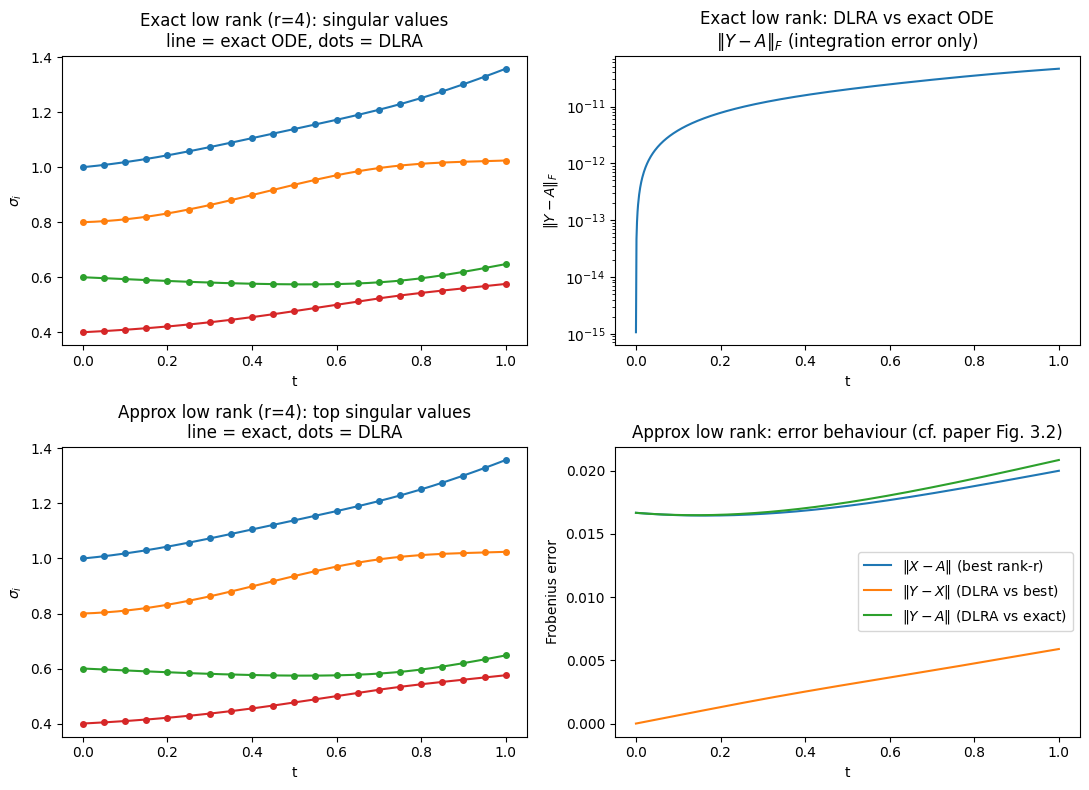

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Top-left: singular values, exact-low-rank case (lines = exact, dots = DLRA).
ax = axes[0, 0]
t = res_exact["t"]
for i in range(res_exact["r"]):
    ax.plot(t, res_exact["sv_exact"][:, i], "-", color=f"C{i}")
    ax.plot(t[::40], res_exact["sv_dlra"][::40, i], "o", color=f"C{i}", ms=4)
ax.set_title(f"Exact low rank (r={res_exact['r']}): singular values\nline = exact ODE, dots = DLRA")
ax.set_xlabel("t"); ax.set_ylabel(r"$\sigma_i$")

# Top-right: DLRA reproduction error, exact-low-rank case.
ax = axes[0, 1]
ax.semilogy(t, np.maximum(res_exact["err_YA"], 1e-16))
ax.set_title("Exact low rank: DLRA vs exact ODE\n$\\|Y-A\\|_F$ (integration error only)")
ax.set_xlabel("t"); ax.set_ylabel(r"$\|Y-A\|_F$")

# Bottom-left: singular values, approx-low-rank case.
ax = axes[1, 0]
t = res_approx["t"]
for i in range(res_approx["r"]):
    ax.plot(t, res_approx["sv_exact"][:, i], "-", color=f"C{i}")
    ax.plot(t[::40], res_approx["sv_dlra"][::40, i], "o", color=f"C{i}", ms=4)
ax.set_title(f"Approx low rank (r={res_approx['r']}): top singular values\nline = exact, dots = DLRA")
ax.set_xlabel("t"); ax.set_ylabel(r"$\sigma_i$")

# Bottom-right: error curves (cf. paper Fig. 3.2).
ax = axes[1, 1]
ax.plot(t, res_approx["err_XA"], label=r"$\|X-A\|$ (best rank-r)")
ax.plot(t, res_approx["err_YX"], label=r"$\|Y-X\|$ (DLRA vs best)")
ax.plot(t, res_approx["err_YA"], label=r"$\|Y-A\|$ (DLRA vs exact)")
ax.set_title("Approx low rank: error behaviour (cf. paper Fig. 3.2)")
ax.set_xlabel("t"); ax.set_ylabel("Frobenius error"); ax.legend()

fig.tight_layout()
plt.show()